# Impor Package / Library

In [ ]:
# --- 1. Pengelolaan File & Sistem ---
import os
import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
import warnings

# --- 2. Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# --- 3. Pengolahan Citra ---
import cv2
from PIL import Image

# --- 4. TensorFlow & Keras Core ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K  # Penting untuk Custom CTC Loss

# --- 5. Spesifik HTR & Preprocessing ---
from tensorflow.keras.layers import StringLookup

# --- 6. Pelatihan & Callbacks ---
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# --- 7. Metrik Evaluasi HTR ---
try:
    from jiwer import cer
except ImportError:
    !pip install jiwer -q
    from jiwer import cer

# --- 8. Konfigurasi Lingkungan ---
warnings.simplefilter(action='ignore', category=FutureWarning)

# Install library untuk splitting folder jika belum ada
!pip install split-folders

import os
import splitfolders
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Cek Hardware
print("TensorFlow Version:", tf.__version__)
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU Terdeteksi: {gpu_devices[0]}")
    # Mengaktifkan memory growth agar RAM GPU tidak langsung penuh
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("PERINGATAN: GPU tidak terdeteksi. Training mungkin akan sangat lambat.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 83.9 MB/s eta 0:00:00
TensorFlow Version: 2.20.0
GPU Terdeteksi: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Data Preparation & Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Menyalin folder dari Drive ke lokal Colab
!cp -r /content/drive/MyDrive/NayaAksara/dataset_training /content/dataset_lokal

In [ ]:
input_folder = '/content/drive/MyDrive/NayaAksara/Master_Dataset' #origin master dataset
output_folder = '/content/drive/MyDrive/NayaAksara/dataset_training' #splitting dataset

# Proses splitting: 70% Train, 15% Val, 15% Test
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .15, .15))

print("✅ Dataset berhasil di-split menjadi 70:15:15")

Copying files: 4196 files [02:18, 30.22 files/s]

✅ Dataset berhasil di-split menjadi 70:15:15


# Data Modelling

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = '/content/drive/MyDrive/NayaAksara/dataset_training'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    base_dir + '/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    base_dir + '/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    base_dir + '/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 2927 images belonging to 20 classes.
Found 619 images belonging to 20 classes.
Found 650 images belonging to 20 classes.


# Training Pertamakali

In [ ]:
import cv2
import numpy as np

def naya_aksara_preprocessing(img):
    img_uint8 = img.astype(np.uint8)
    kernel = np.ones((2, 2), np.uint8)
    img_dilated = cv2.dilate(img_uint8, kernel, iterations=1)
    return img_dilated.reshape((128, 128, 1)).astype(np.float32) / 255.0

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Konfigurasi: Hanya pakai preprocessing_function kustom kita
train_datagen_clean = ImageDataGenerator(
    preprocessing_function=naya_aksara_preprocessing,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_test_datagen_clean = ImageDataGenerator(
    preprocessing_function=naya_aksara_preprocessing
)

# Load Data
train_generator = train_datagen_clean.flow_from_directory(
    base_dir + '/train', target_size=(128, 128), batch_size=32, color_mode='grayscale', class_mode='categorical'
)

val_generator = val_test_datagen_clean.flow_from_directory(
    base_dir + '/val', target_size=(128, 128), batch_size=32, color_mode='grayscale', class_mode='categorical'
)

test_generator = val_test_datagen_clean.flow_from_directory(
    base_dir + '/test', target_size=(128, 128), batch_size=32, color_mode='grayscale', class_mode='categorical', shuffle=False
)

Found 2927 images belonging to 20 classes.
Found 619 images belonging to 20 classes.
Found 650 images belonging to 20 classes.


In [ ]:
import tensorflow as tf

class NayaAksaraPremiumGuard(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')

        print(f"[Guard] Epoch {epoch+1} Report:")
        print(f"   > Akurasi Latihan: {acc:.4f}")
        print(f"   > Akurasi Validasi: {val_acc:.4f}")

        if acc > 0.90 and val_acc > 0.90:
            print("Target tercapai! Menghentikan latihan.")
            self.model.stop_training = True

In [ ]:

model = build_model_128()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


callbacks_final = [
    NayaAksaraPremiumGuard(),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]


history_final = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks_final
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.0771 - loss: 5.8447[Guard] Epoch 1 Report:
   > Akurasi Latihan: 0.0981
   > Akurasi Validasi: 0.0501
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 264ms/step - accuracy: 0.0981 - loss: 4.2039 - val_accuracy: 0.0501 - val_loss: 3.0548 - learning_rate: 5.0000e-04
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.1574 - loss: 2.8458[Guard] Epoch 2 Report:
   > Akurasi Latihan: 0.1558
   > Akurasi Validasi: 0.0501
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - accuracy: 0.1558 - loss: 2.8176 - val_accuracy: 0.0501 - val_loss: 3.1128 - learning_rate: 5.0000e-04
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.2025 - loss: 2.5941[Guard] Epoch 3 Report:
   > Akurasi Latihan: 0.2115
   > Akurasi Validasi: 0.0501
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.2115 - loss: 2.5517 - val_accuracy: 0.0501 - val_loss: 3.3151 - learning_rate: 5.0000e-04
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accu

In [ ]:
# Tentukan folder penyimpanan
save_dir = '/content/drive/MyDrive/NayaAksara/model2/'
os.makedirs(save_dir, exist_ok=True)

# Simpan model final
model_name = 'v1.keras'
model.save(os.path.join(save_dir, model_name))

print(f"✅ Model berhasil diamankan di: {save_dir}{model_name}")

✅ Model berhasil diamankan di: /content/drive/MyDrive/NayaAksara/model2/v1.keras


In [ ]:
# Evaluasi model pada data test yang belum pernah dilihat sama sekali
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print("-" * 35)
print(f"📊 HASIL EVALUASI AKHIR (TEST SET)")
print(f"Loss     : {test_loss:.4f}")
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("-" * 35)

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.8277 - loss: 0.5810
-----------------------------------
📊 HASIL EVALUASI AKHIR (TEST SET)
Loss     : 0.5810
Accuracy : 0.8277 (82.77%)
-----------------------------------


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step

📝 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          ba       0.97      0.82      0.89        34
          ca       0.93      0.85      0.89        33
          da       0.88      0.85      0.86        33
         dha       0.96      0.84      0.90        32
          ga       0.93      0.84      0.89        32
          ha       1.00      0.75      0.86        32
          ja       0.93      0.88      0.90        32
          ka       0.87      0.82      0.84        33
          la       0.93      0.88      0.90        32
          ma       0.97      0.91      0.94        33
          na       0.92      0.70      0.79        33
         nga       0.93      0.78      0.85        32
         nya       0.90      0.88      0.89        32
          pa       0.29      0.94      0.45        32
          ra       0.93      0.81      0.87        32
          sa       1.00      0.82      0.90        33
          ta  

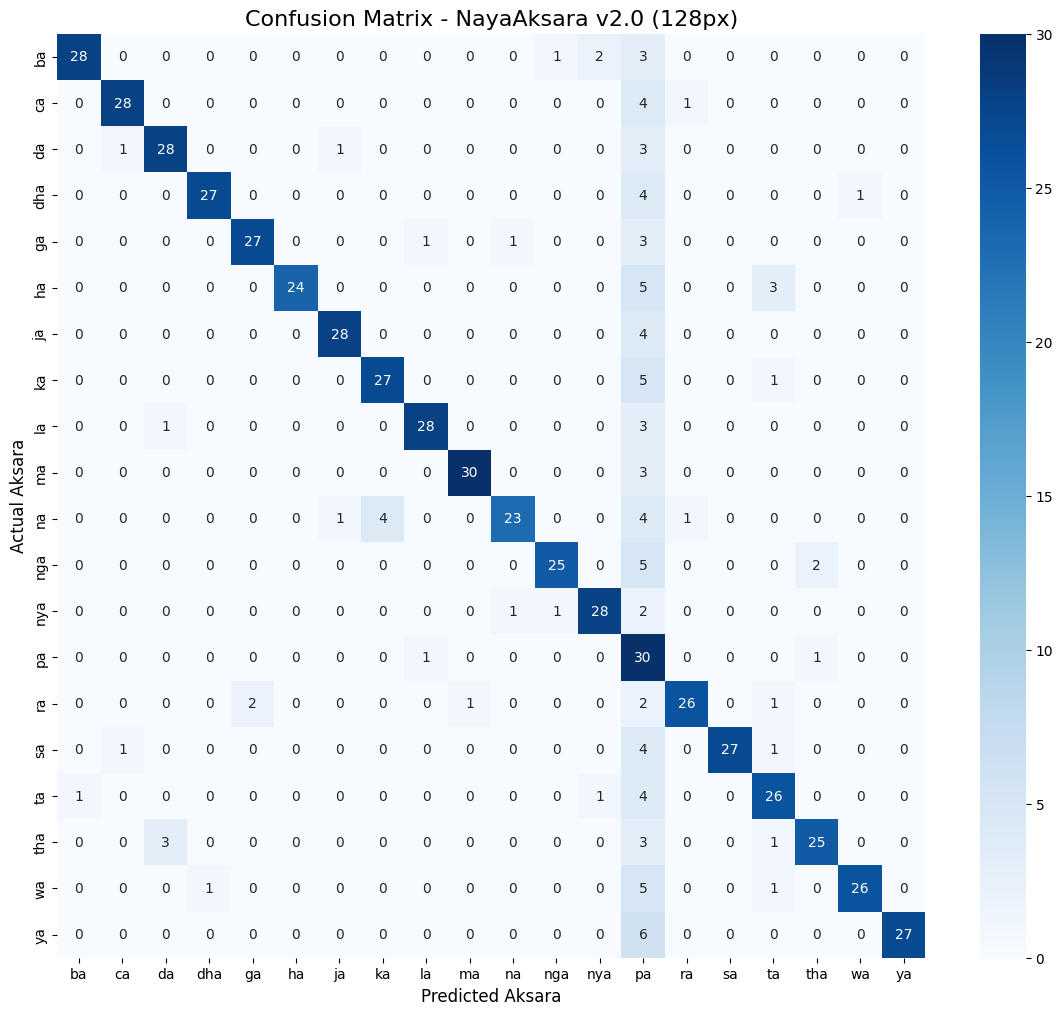

✅ Confusion Matrix disimpan di: /content/drive/MyDrive/NayaAksara/reports/confusion_matrix_v2_final.png


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Pastikan generator di-reset agar urutan file sinkron dengan label
test_generator.reset()

# 2. Ambil Prediksi
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1) # Ambil indeks kelas dengan probabilitas tertinggi

# 3. Ambil Label Asli
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 4. Cetak Classification Report (Precision, Recall, F1-Score)
print("\n📝 CLASSIFICATION REPORT:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 5. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - NayaAksara v2.0 (128px)', fontsize=16)
plt.ylabel('Actual Aksara', fontsize=12)
plt.xlabel('Predicted Aksara', fontsize=12)

# Simpan gambar ke Drive untuk Laporan
save_plot_path = '/content/drive/MyDrive/NayaAksara/reports/confusion_matrix_v2_final.png'
os.makedirs(os.path.dirname(save_plot_path), exist_ok=True)
plt.savefig(save_plot_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"✅ Confusion Matrix disimpan di: {save_plot_path}")

# Fine Tuning 1


In [ ]:
import tensorflow as tf
import os

# Path model
model_path = '/content/drive/MyDrive/NayaAksara/model2/v1.keras'

if os.path.exists(model_path):
    print("Menarik model untuk di-fine-tune...")
    model = tf.keras.models.load_model(model_path)
else:
    print("⚠️ Model tidak ditemukan, pastikan path benar!")


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Menarik model untuk di-fine-tune...


In [ ]:
# 1. Custom Guard tetap terpasang
class NayaAksaraPremiumGuard(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        if acc > 0.90 and val_acc > 0.90:
            print("\n Menghentikan Training...")
            self.model.stop_training = True

# 2. Early Stopping yang lebih sabar
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# 3. Learning Rate Scheduler
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

In [ ]:
history_finetune = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[NayaAksaraPremiumGuard(), early_stop, reduce_lr]
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 253ms/step - accuracy: 0.5938 - loss: 1.2957 - val_accuracy: 0.6220 - val_loss: 1.2246 - learning_rate: 1.0000e-04
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.6027 - loss: 1.2872 - val_accuracy: 0.5735 - val_loss: 2.6915 - learning_rate: 1.0000e-04
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.6102 - loss: 1.2457 - val_accuracy: 0.6187 - val_loss: 2.0811 - learning_rate: 1.0000e-04
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.6262 - loss: 1.1875 - val_accuracy: 0.6397 - val_loss: 2.1043 - learning_rate: 1.0000e-04
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - accuracy: 0.6505 - loss: 1.1449 - val_accuracy: 0.4378 - val_loss: 2.8518 - learning_rate: 1.0000e-04
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6343 - loss: 1.1472
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy

In [ ]:
# Evaluasi pada Test Set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print("-" * 35)
print(f"📊 HASIL PENGUJIAN AKHIR")
print(f"Loss     : {test_loss:.4f}")
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("-" * 35)

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.8262 - loss: 0.5630
-----------------------------------
📊 HASIL PENGUJIAN AKHIR
Loss     : 0.5630
Accuracy : 0.8262 (82.62%)
-----------------------------------


21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step

📝 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          ba       1.00      0.71      0.83        34
          ca       0.90      0.82      0.86        33
          da       0.88      0.85      0.86        33
         dha       0.96      0.84      0.90        32
          ga       0.93      0.88      0.90        32
          ha       0.42      0.75      0.54        32
          ja       1.00      0.84      0.92        32
          ka       0.87      0.82      0.84        33
          la       0.97      0.88      0.92        32
          ma       1.00      0.88      0.94        33
          na       0.82      0.70      0.75        33
         nga       0.92      0.72      0.81        32
         nya       0.70      0.88      0.78        32
          pa       0.93      0.84      0.89        32
          ra       1.00      0.84      0.92        32
          sa       0.96      0.82      0.89        33
          ta  

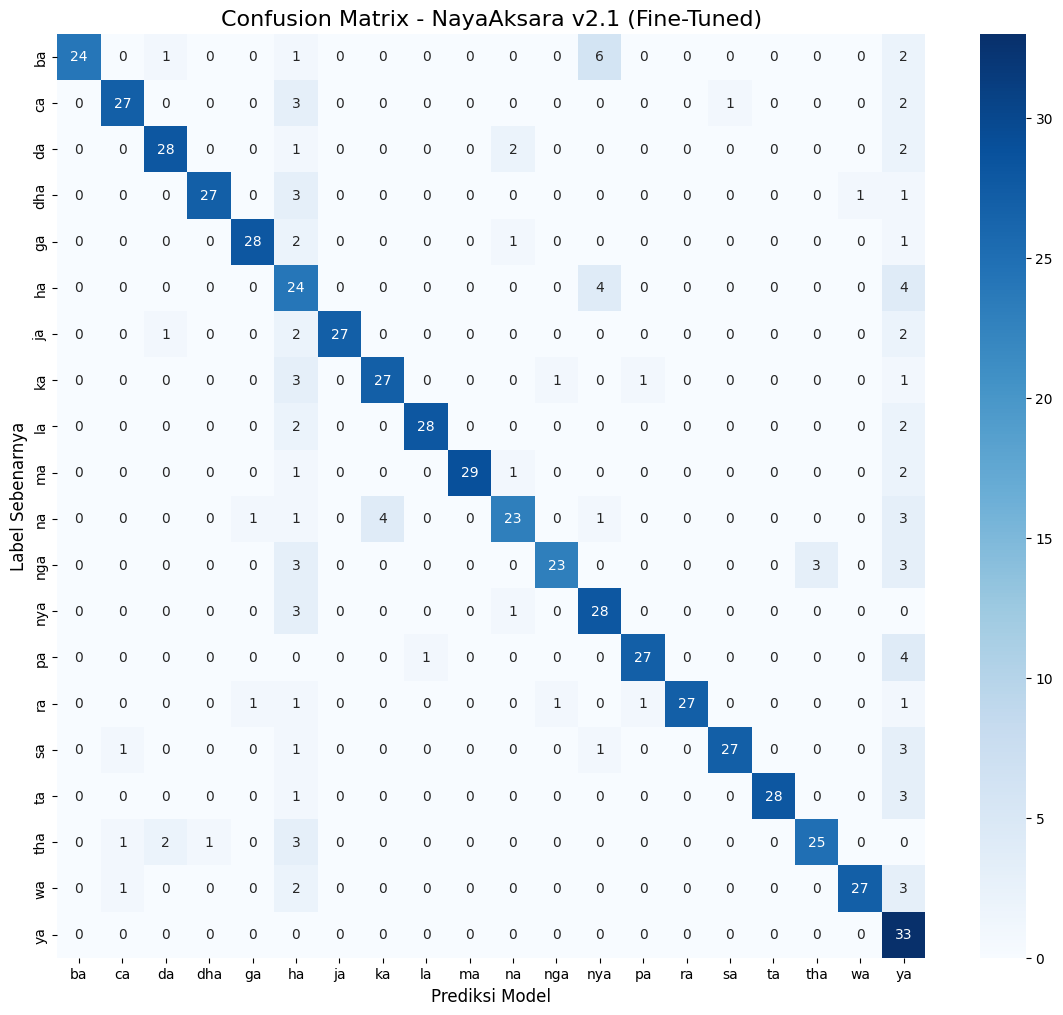

✅ Visualisasi disimpan di: /content/drive/MyDrive/NayaAksara/reports/confusion_matrix_v2_final.png


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Ambil prediksi dari model
test_generator.reset() # WAJIB di-reset agar urutan file tetap konsisten
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# 2. Ambil label asli dan nama kelas
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 3. Classification Report (Precision, Recall, F1-Score)
print("\n📝 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Membuat Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - NayaAksara v2.1 (Fine-Tuned)', fontsize=16)
plt.ylabel('Label Sebenarnya', fontsize=12)
plt.xlabel('Prediksi Model', fontsize=12)

# Simpan gambar untuk kebutuhan Laporan Capstone
report_path = '/content/drive/MyDrive/NayaAksara/reports/confusion_matrix_v2_final.png'
plt.savefig(report_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Visualisasi disimpan di: {report_path}")

In [ ]:
# Tentukan folder penyimpanan
save_dir = '/content/drive/MyDrive/NayaAksara/model2/'
os.makedirs(save_dir, exist_ok=True)

# Simpan model final
model_name = 'v2.keras'
model.save(os.path.join(save_dir, model_name))

print(f"✅ Model berhasil diamankan di: {save_dir}{model_name}")

✅ Model berhasil diamankan di: /content/drive/MyDrive/NayaAksara/model2/v2.keras


# Fine Tuning 2

In [ ]:
from tensorflow.keras import layers, models

def build_model_128_aligned():
    model = models.Sequential([
        layers.Input(shape=(128, 128, 1)),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.6),
        layers.Dense(20, activation='softmax')
    ])
    return model

In [ ]:
import os
import tensorflow as tf
model = build_model_128_aligned()

# 2. Path model hasil Fine-Tuning 1
model_path = '/content/drive/MyDrive/NayaAksara/model2/v2.keras'

if os.path.exists(model_path):
    print("🧠 Menyuntikkan bobot baru ke arsitektur Aligned (Dropout 0.6)...")

    old_model = tf.keras.models.load_model(model_path)

    model.set_weights(old_model.get_weights())
    print("✅ Berhasil! Sekarang model kamu punya 'ingatan' lama dengan 'armor' baru.")
else:
    print("❌ ERROR: File v2.keras tidak ditemukan!")

# 3. Re-Compile dengan LR yang sangat halus
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

🧠 Menyuntikkan bobot baru ke arsitektur Aligned (Dropout 0.6)...
✅ Berhasil! Sekarang model kamu punya 'ingatan' lama dengan 'armor' baru.


In [ ]:
import tensorflow as tf

class NayaAksaraAlignmentGuard(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        gap = abs(train_acc - val_acc)

        print(f"\n⚖️  [Alignment Report] Epoch {epoch+1}:")
        print(f"   > Gap Acc (Train vs Val): {gap:.4f}")

        # Logika: Jika akurasi sudah bagus tapi jomplang (Gap > 0.15), beri peringatan
        if gap > 0.15 and train_acc > 0.80:
            print(" WARNING: Generalization Gap terlalu lebar! Model mulai menghafal.")

        # Berhenti jika target selaras tercapai
        if val_acc > 0.80 and gap < 0.08:
            print("   🚀 SUCCESS: Model sudah selaras dan akurat! Menghentikan latihan.")
            self.model.stop_training = True

In [ ]:
# Setup Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)


print("Memulai Fine-Tuning Tahap 2")
history_v2_2 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[
        NayaAksaraAlignmentGuard(),
        early_stop,
        reduce_lr
    ]
)

Memulai Fine-Tuning Tahap 2
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.5533 - loss: 1.4193
⚖️  [Alignment Report] Epoch 1:
   > Gap Acc (Train vs Val): 0.0077
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 279ms/step - accuracy: 0.5658 - loss: 1.3790 - val_accuracy: 0.5735 - val_loss: 2.4856 - learning_rate: 5.0000e-05
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5794 - loss: 1.3372
⚖️  [Alignment Report] Epoch 2:
   > Gap Acc (Train vs Val): 0.0590
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.5791 - loss: 1.3386 - val_accuracy: 0.6381 - val_loss: 1.9070 - learning_rate: 5.0000e-05
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5880 - loss: 1.3225
⚖️  [Alignment Report] Epoch 3:
   > Gap Acc (Train vs Val): 0.0394
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.5774 - loss: 1.3325 - val_accuracy: 0.5380 - val_loss: 3.0071 - learning_rate: 5.0000e-05
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5889 -

In [ ]:
# 1. Jalankan evaluasi pada generator test
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print("-" * 35)
print(f"📊 HASIL EVALUASI AKHIR")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("-" * 35)

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.8492 - loss: 0.5320
-----------------------------------
📊 HASIL EVALUASI AKHIR
Test Loss     : 0.5320
Test Accuracy : 0.8492 (84.92%)
-----------------------------------


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Reset generator agar urutan file sinkron dengan label
test_generator.reset()

# 2. Ambil prediksi dari model
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# 3. Ambil label asli dari generator
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 4. Cetak Classification Report
print("\n📝 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step

📝 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          ba       0.90      0.82      0.86        34
          ca       1.00      0.85      0.92        33
          da       1.00      0.88      0.94        33
         dha       1.00      0.84      0.92        32
          ga       0.88      0.88      0.88        32
          ha       0.57      0.84      0.68        32
          ja       0.88      0.88      0.88        32
          ka       0.87      0.82      0.84        33
          la       1.00      0.88      0.93        32
          ma       1.00      0.88      0.94        33
          na       0.92      0.73      0.81        33
         nga       1.00      0.78      0.88        32
         nya       0.90      0.88      0.89        32
          pa       1.00      0.88      0.93        32
          ra       0.96      0.84      0.90        32
          sa       1.00      0.82      0.90        33
          ta  

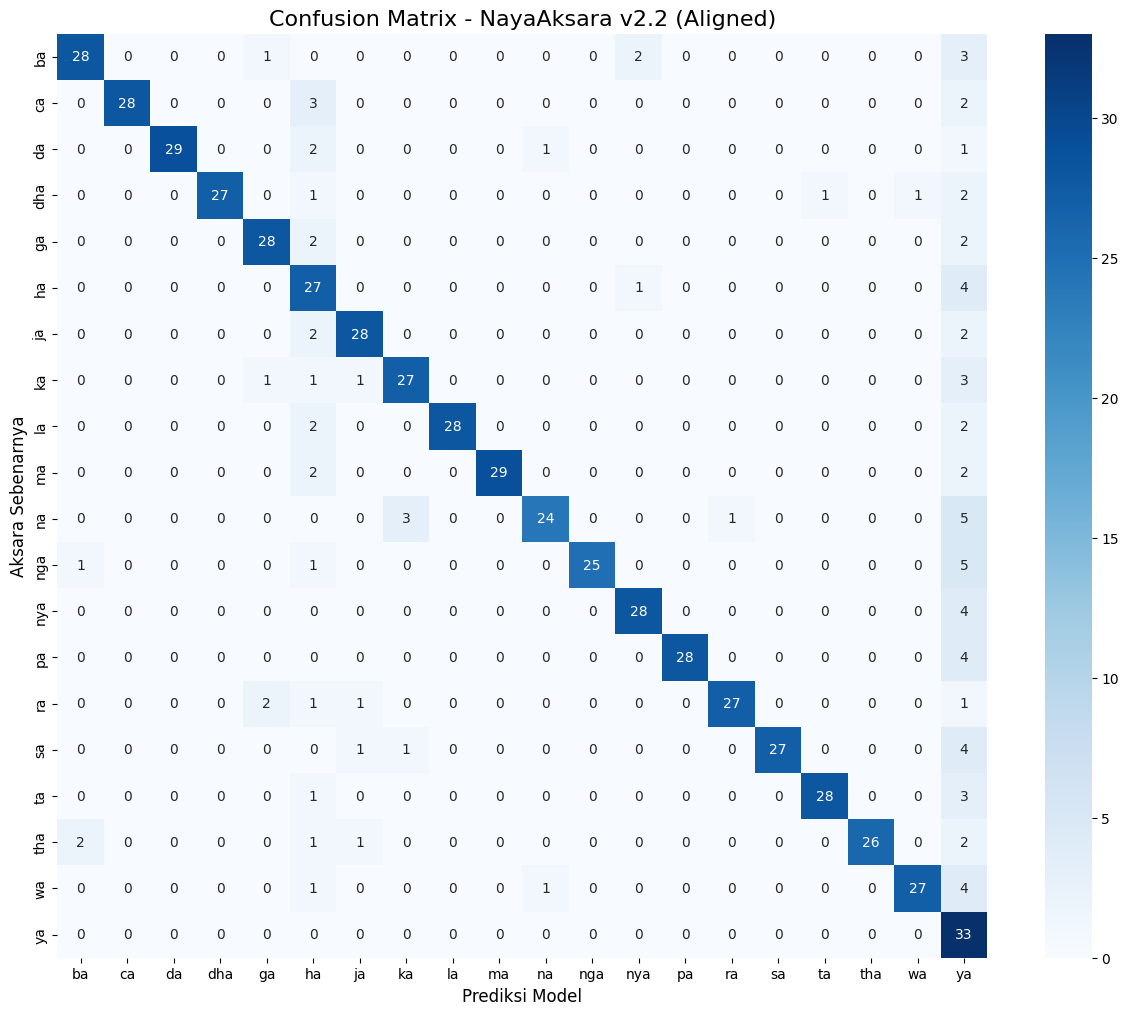

✅ Confusion Matrix disimpan di: /content/drive/MyDrive/NayaAksara/reports/confusion_matrix_v2_aligned.png


In [ ]:
# 1. Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Setup Plot
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - NayaAksara v2.2 (Aligned)', fontsize=16)
plt.ylabel('Aksara Sebenarnya', fontsize=12)
plt.xlabel('Prediksi Model', fontsize=12)

# 3. Simpan ke Drive untuk Laporan
report_save_path = '/content/drive/MyDrive/NayaAksara/reports/confusion_matrix_v2_aligned.png'
plt.savefig(report_save_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"✅ Confusion Matrix disimpan di: {report_save_path}")

In [ ]:
# Tentukan folder penyimpanan
save_dir = '/content/drive/MyDrive/NayaAksara/model2/'
os.makedirs(save_dir, exist_ok=True)

# Simpan model final
model_name = 'v3.keras'
model.save(os.path.join(save_dir, model_name))

print(f"✅ Model berhasil diamankan di: {save_dir}{model_name}")

✅ Model berhasil diamankan di: /content/drive/MyDrive/NayaAksara/model2/v3.keras


# Fine Tuning 3


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_naya_aksara_functional(input_shape=(128, 128, 1), num_classes=20):
    inputs = layers.Input(shape=input_shape, name="input_layer")

    # Blok 1 & 2
    x = layers.Conv2D(32, (3, 3), activation='relu', name="block1_conv")(inputs)
    x = layers.BatchNormalization(name="block1_bn")(x)
    x = layers.MaxPooling2D((2, 2), name="block1_pool")(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', name="block2_conv")(x)
    x = layers.BatchNormalization(name="block2_bn")(x)
    x = layers.MaxPooling2D((2, 2), name="block2_pool")(x)

    # Blok 3 & 4
    x = layers.Conv2D(128, (3, 3), activation='relu', name="block3_conv")(x)
    x = layers.BatchNormalization(name="block3_bn")(x)
    x = layers.MaxPooling2D((2, 2), name="block3_pool")(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', name="block4_conv")(x)
    x = layers.BatchNormalization(name="block4_bn")(x)
    x = layers.MaxPooling2D((2, 2), name="block4_pool")(x)

    # Head
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(512, activation='relu', name="dense_top")(x)
    x = layers.Dropout(0.6, name="dropout_top")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output_layer")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="NayaAksara_Functional_Surgeon")
    return model

# 1. Bangun ulang model
model = build_naya_aksara_functional()

# 2. Coba bobot kembali
path_v3 = '/content/v3.keras'
model.load_weights(path_v3)

print("✅ Model Functional API sekarang identik dengan v3 dan bobot berhasil disuntikkan!")

✅ Model Functional API sekarang identik dengan v3 dan bobot berhasil disuntikkan!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentasi yang lebih "sopan"
train_datagen_light = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,      # Dikurangi dari sebelumnya
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen_light.flow_from_directory(
    '/content/dataset_lokal/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/dataset_lokal/val',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'
)

Found 2927 images belonging to 20 classes.
Found 619 images belonging to 20 classes.


In [ ]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)


class NayaAksaraSurgeonGuard(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        gap = abs(train_acc - val_acc)

        print(f"\n🛡️  [Surgeon Report] Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {gap:.4f}")
        if gap < 0.05 and val_acc > 0.85:
            print("Menghentikan pelatihan secara otomatis...")
            self.model.stop_training = True

callbacks = [
    NayaAksaraSurgeonGuard(),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

print("Ready...")

Ready...


In [ ]:
import tensorflow as tf
print("GPU Available: ", tf.config.list_physical_devices('GPU'))
EPOCHS = 50

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:


print("🚀 Memulai Fine Tuning")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

🚀 Memulai Fine Tuning
Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6617 - loss: 1.9253
🛡️  [Surgeon Report] Train: 0.6666 | Val: 0.7754 | Gap: 0.1089
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.6666 - loss: 1.8590 - val_accuracy: 0.7754 - val_loss: 1.6244 - learning_rate: 1.0000e-05
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6628 - loss: 1.7671
🛡️  [Surgeon Report] Train: 0.6727 | Val: 0.7900 | Gap: 0.1173
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.6727 - loss: 1.7392 - val_accuracy: 0.7900 - val_loss: 1.4795 - learning_rate: 1.0000e-05
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6693 - loss: 1.7053
🛡️  [Surgeon Report] Train: 0.6693 | Val: 0.7964 | Gap: 0.1272
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.6693 - loss: 1.6954 - val_accuracy: 0.7964 - val_loss: 1.4223 - learning_rate: 1.0000e-05
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6865 - loss: 1.6581
🛡️  [Sur

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Definisi Generator untuk Data Test
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/dataset_lokal/test', # Pastikan path ini sesuai hasil unzip tadi
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False # WAJIB False untuk Confusion Matrix
)

# 2. Evaluasi Model pada Data Test
print("\n🔍 Mengevaluasi Model pada Data Test...")
test_loss, test_acc = model.evaluate(test_generator)

print("-" * 35)
print(f"📊 HASIL EVALUASI AKHIR")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("-" * 35)

Found 650 images belonging to 20 classes.

🔍 Mengevaluasi Model pada Data Test...
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9462 - loss: 0.9359
-----------------------------------
📊 HASIL EVALUASI AKHIR
Test Accuracy : 94.62%
Test Loss     : 0.9359
-----------------------------------


🚀 Menghitung prediksi untuk Confusion Matrix...
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


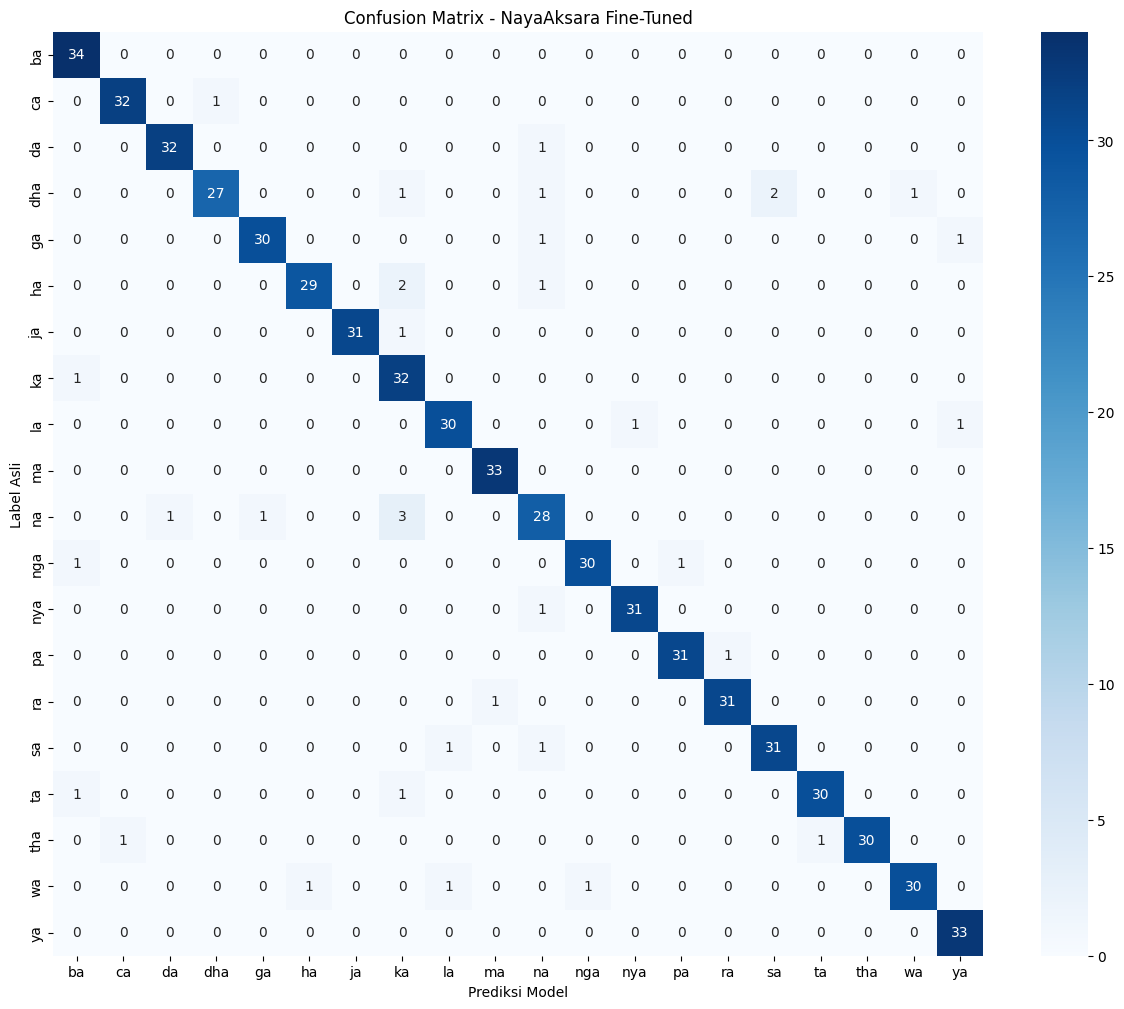


📝 Classification Report:
              precision    recall  f1-score   support

          ba       0.92      1.00      0.96        34
          ca       0.97      0.97      0.97        33
          da       0.97      0.97      0.97        33
         dha       0.96      0.84      0.90        32
          ga       0.97      0.94      0.95        32
          ha       0.97      0.91      0.94        32
          ja       1.00      0.97      0.98        32
          ka       0.80      0.97      0.88        33
          la       0.94      0.94      0.94        32
          ma       0.97      1.00      0.99        33
          na       0.82      0.85      0.84        33
         nga       0.97      0.94      0.95        32
         nya       0.97      0.97      0.97        32
          pa       0.97      0.97      0.97        32
          ra       0.97      0.97      0.97        32
          sa       0.94      0.94      0.94        33
          ta       0.97      0.94      0.95        32
 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Ambil prediksi dari model
print("🚀 Menghitung prediksi untuk Confusion Matrix...")
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# 2. Ambil label asli
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 3. Buat Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Visualisasi dengan Seaborn
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - NayaAksara Fine-Tuned')
plt.ylabel('Label Asli')
plt.xlabel('Prediksi Model')
plt.show()

# 5. Tampilkan Classification Report
print("\n📝 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
import os

# Nama file model
model_filename = 'finetune3-new.keras'

# 1. Simpan ke Lokal Colab (/content/)
local_save_path = f'/content/{model_filename}'
model.save(local_save_path)
print(f"✅ Model disimpan di Lokal: {local_save_path}")

# 2. Simpan ke Google Drive
drive_save_folder = '/content/drive/MyDrive/NayaAksara/model3/'
os.makedirs(drive_save_folder, exist_ok=True)
drive_save_path = os.path.join(drive_save_folder, model_filename)

# Copy dari lokal ke drive (lebih stabil daripada model.save langsung ke drive)
!cp "{local_save_path}" "{drive_save_path}"
print(f"✅ Model disalin ke Google Drive: {drive_save_path}")

✅ Model disimpan di Lokal: /content/finetune3-new.keras
✅ Model disalin ke Google Drive: /content/drive/MyDrive/NayaAksara/model3/finetune3-new.keras


# Inference Testing

Mapping Clas JSON

In [ ]:
import json
import os

# 1. Ambil mapping dari generator
class_indices = train_generator.class_indices
class_mapping = {int(v): k for k, v in class_indices.items()}

# 2. Simpan ke Lokal Colab
local_json_path = '/content/class_mapping.json'
with open(local_json_path, 'w') as f:
    json.dump(class_mapping, f, indent=4)

print(f"✅ Mapping berhasil disimpan secara lokal di: {local_json_path}")

# 3. Simpan ke Google Drive
drive_json_folder = '/content/drive/MyDrive/NayaAksara/jsonmap/'
os.makedirs(drive_json_folder, exist_ok=True)
drive_json_path = os.path.join(drive_json_folder, 'class_mapping.json')

!cp "{local_json_path}" "{drive_json_path}"
print(f"✅ Mapping berhasil dicadangkan ke Drive: {drive_json_path}")


print("\nIsi Mapping Aksara:")
print(json.dumps(class_mapping, indent=4))

✅ Mapping berhasil disimpan secara lokal di: /content/class_mapping.json
✅ Mapping berhasil dicadangkan ke Drive: /content/drive/MyDrive/NayaAksara/jsonmap/class_mapping.json

Isi Mapping Aksara:
{
    "0": "ba",
    "1": "ca",
    "2": "da",
    "3": "dha",
    "4": "ga",
    "5": "ha",
    "6": "ja",
    "7": "ka",
    "8": "la",
    "9": "ma",
    "10": "na",
    "11": "nga",
    "12": "nya",
    "13": "pa",
    "14": "ra",
    "15": "sa",
    "16": "ta",
    "17": "tha",
    "18": "wa",
    "19": "ya"
}


Inference Testing

📤 Silakan pilih gambar aksara Jawa (format .jpg, .png, .jpeg):


Saving meow.png to meow.png


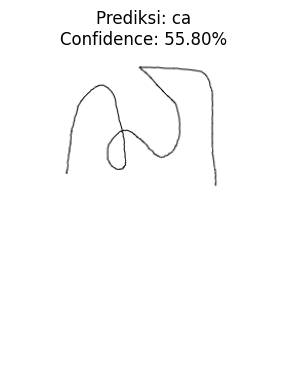

---
File: meow.png
Hasil Klasifikasi: Aksara CA
Tingkat Keyakinan: 55.80%
---


In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files

def run_naya_aksara_inference():
    #
    model_path = '/content/finetune3-new.keras'
    mapping_path = '/content/class_mapping.json'

    if not os.path.exists(model_path):
        print("❌ Model tidak ditemukan! Pastikan model sudah disimpan.")
        return

    model_final = load_model(model_path)
    with open(mapping_path, 'r') as f:
        labels = json.load(f)

    # 2. Fitur Upload Gambar
    print("📤 Silakan pilih gambar aksara Jawa (format .jpg, .png, .jpeg):")
    uploaded = files.upload()

    for fn in uploaded.keys():

        img_path = fn
        img = image.load_img(img_path, target_size=(128, 128), color_mode='grayscale')
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # 4. Prediksi
        predictions = model_final.predict(img_array, verbose=0)
        score = np.max(predictions)
        class_idx = str(np.argmax(predictions))
        result_label = labels[class_idx]

        # 5. Visualisasi Hasil
        plt.figure(figsize=(4, 4))
        plt.imshow(image.load_img(img_path))
        plt.title(f"Prediksi: {result_label}\nConfidence: {score*100:.2f}%")
        plt.axis('off')
        plt.show()

        print(f"---")
        print(f"File: {fn}")
        print(f"Hasil Klasifikasi: Aksara {result_label.upper()}")
        print(f"Tingkat Keyakinan: {score*100:.2f}%")
        print(f"---")

run_naya_aksara_inference()

# Other

In [ ]:
import os

# 1. Tentukan Nama Folder Model
model_folder_name = 'savemodel-nayaaksara'

# 2. Export sebagai SavedModel (Format Folder)
# Di Keras 3, gunakan .export() untuk menghasilkan SavedModel
local_model_path = f'/content/{model_folder_name}'

print(f"Sedang mengekspor model ke format SavedModel...")
model.export(local_model_path)
print(f"Model berhasil diekspor di Lokal Colab: {local_model_path}")

# 3. Tentukan Path di Google Drive
drive_model_folder = '/content/drive/MyDrive/NayaAksara/model3/'
os.makedirs(drive_model_folder, exist_ok=True)
drive_model_path = os.path.join(drive_model_folder, model_folder_name)

# 4. Salin Folder dari Lokal ke Drive
# Gunakan -r karena SavedModel adalah satu folder utuh
!cp -r "{local_model_path}" "{drive_model_path}"
print(f"✅ Folder SavedModel berhasil dicadangkan ke Drive: {drive_model_path}")

Sedang mengekspor model ke format SavedModel...
Saved artifact at '/content/savemodel-nayaaksara'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  138497975262224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983958096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983959632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983960016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983955024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983957328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983955216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983958864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983957904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138497983961168: Tensor

In [ ]:
!pip freeze > requirements.txt